##Доработка

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize

original_outliers = len(data_encoded[data_encoded['SalesRtgPer'] > data_encoded['SalesRtgPer'].quantile(0.99)])
print(f"Исходное количество выбросов (99% перцентиль): {original_outliers}")

Исходное количество выбросов (99% перцентиль): 15256


In [ ]:
Q1 = data_encoded['SalesRtgPer'].quantile(0.25)
Q3 = data_encoded['SalesRtgPer'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5*IQR

iqr_outliers = len(data_encoded[data_encoded['SalesRtgPer'] > upper_bound])
print(f"\nМетод IQR (1.5*IQR):")
print(f"Граница: {upper_bound:.2f}")
print(f"Выбросов: {iqr_outliers} ({iqr_outliers/len(data_encoded)*100:.1f}% данных)")


Метод IQR (1.5*IQR):
Граница: 2.11
Выбросов: 85565 (5.6% данных)


In [ ]:
from scipy import stats
z_scores = stats.zscore(data_encoded['SalesRtgPer'])
z_outliers = len(data_encoded[abs(z_scores) > 3])
print(f"\nZ-Score (3σ):")
print(f"Выбросов: {z_outliers} ({z_outliers/len(data_encoded)*100:.1f}% данных)")


Z-Score (3σ):
Выбросов: 33985 (2.2% данных)


In [ ]:
methods = {
    'IQR (1.5*IQR)': {'outliers': iqr_outliers},
    'Z-Score (3σ)': {'outliers': z_outliers},
}

pd.DataFrame(methods).T

,outliers
IQR (1.5*IQR),85565
Z-Score (3σ),33985


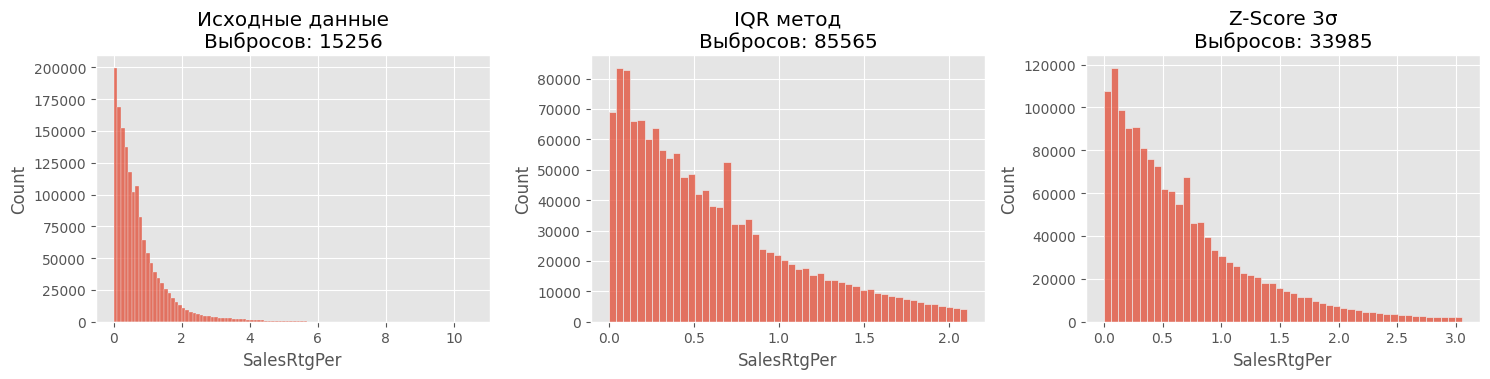

In [ ]:
plt.figure(figsize=(15, 10))

# Исходные данные
plt.subplot(3, 3, 1)
sns.histplot(data_encoded['SalesRtgPer'], bins=100)
plt.title(f'Исходные данные\nВыбросов: {original_outliers}')

# IQR
plt.subplot(3, 3, 2)
sns.histplot(data_encoded[data_encoded['SalesRtgPer'] <= upper_bound]['SalesRtgPer'], bins=50)
plt.title(f'IQR метод\nВыбросов: {iqr_outliers}')

# Z-Score
plt.subplot(3, 3, 3)
sns.histplot(data_encoded[abs(z_scores) <= 3]['SalesRtgPer'], bins=50)
plt.title(f'Z-Score 3σ\nВыбросов: {z_outliers}')

plt.tight_layout()
plt.show()

###Логарифмирование


Исходные статистики:
count    1.528101e+06
mean     7.386783e-01
std      7.710098e-01
min      0.000000e+00
25%      2.201602e-01
50%      5.145640e-01
75%      9.745903e-01
max      1.053848e+01
Name: SalesRtgPer, dtype: float64


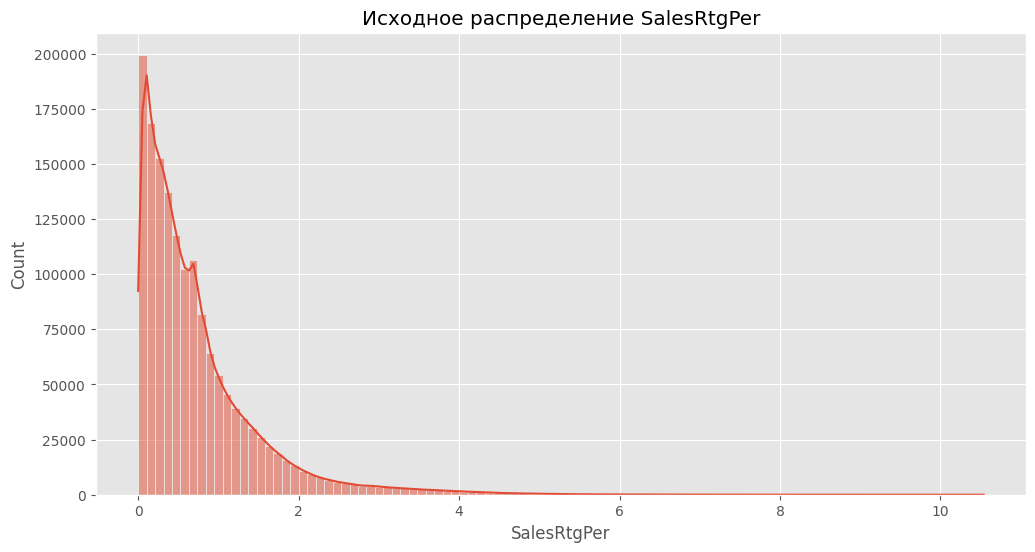

In [ ]:
# БЫЛО
# Основные статистики
print("Исходные статистики:")
print(data_encoded['SalesRtgPer'].describe())

# Визуализация распределения
plt.figure(figsize=(12, 6))
sns.histplot(data_encoded['SalesRtgPer'], bins=100, kde=True)
plt.title('Исходное распределение SalesRtgPer')
plt.show()


Статистики после логарифмирования:
count    1.528101e+06
mean     4.812975e-01
std      3.567683e-01
min      0.000000e+00
25%      1.989822e-01
50%      4.151276e-01
75%      6.803610e-01
max      2.445688e+00
Name: SalesRtgPer_log, dtype: float64


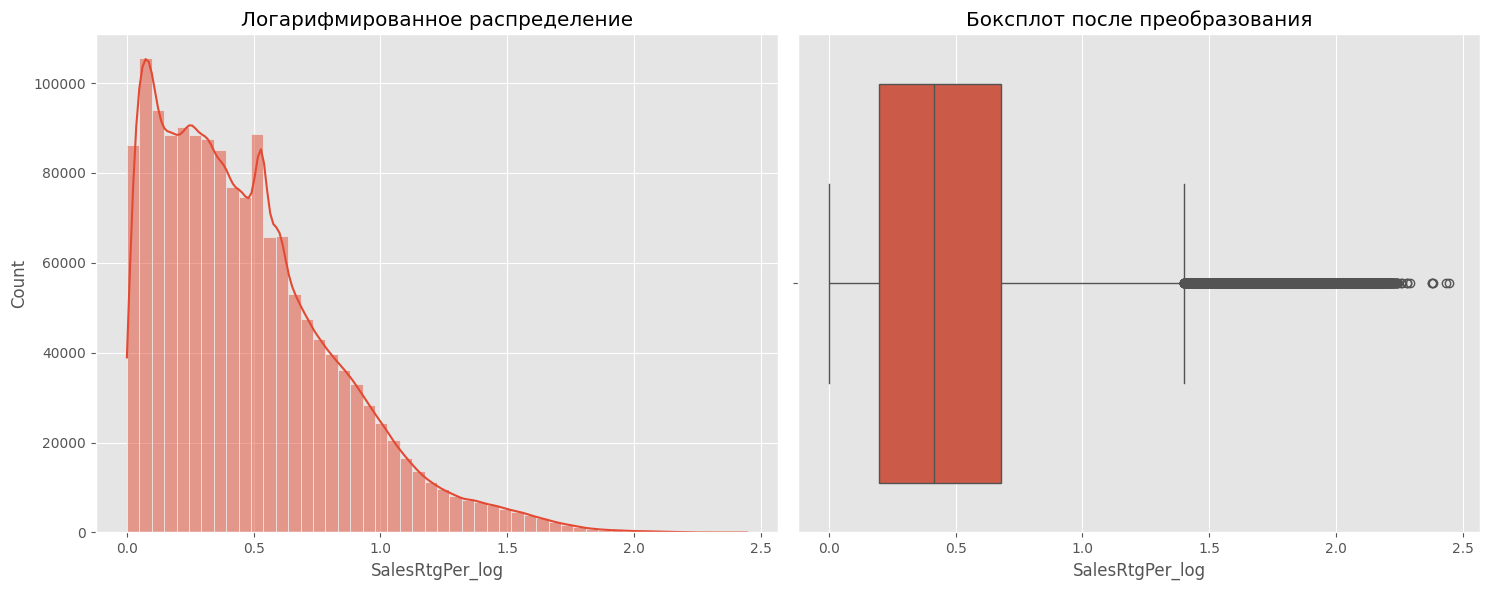

In [ ]:
# Добавляем константу для обработки нулевых значений
data_encoded['SalesRtgPer_log'] = np.log1p(data_encoded['SalesRtgPer'])  # log(1 + x)

# Проверяем результат преобразования
print("\nСтатистики после логарифмирования:")
print(data_encoded['SalesRtgPer_log'].describe())

# Визуализация
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(data_encoded['SalesRtgPer_log'], bins=50, kde=True)
plt.title('Логарифмированное распределение')

plt.subplot(1, 2, 2)
sns.boxplot(x=data_encoded['SalesRtgPer_log'])
plt.title('Боксплот после преобразования')

plt.tight_layout()
plt.show()

In [ ]:
# Вычисляем коэффициент асимметрии до и после
skew_original = data_encoded['SalesRtgPer'].skew()
skew_log = data_encoded['SalesRtgPer_log'].skew()

print(f"\nКоэффициент асимметрии:")
print(f"До преобразования: {skew_original:.2f}")
print(f"После преобразования: {skew_log:.2f}")

# Проверяем выбросы после преобразования
Q1_log = data_encoded['SalesRtgPer_log'].quantile(0.25)
Q3_log = data_encoded['SalesRtgPer_log'].quantile(0.75)
IQR_log = Q3_log - Q1_log
upper_bound_log = Q3_log + 1.5 * IQR_log

print(f"\nГраница выбросов после преобразования: {upper_bound_log:.2f}")
print(f"Выбросов после преобразования: {(data_encoded['SalesRtgPer_log'] > upper_bound_log).sum()}")


Коэффициент асимметрии:
До преобразования: 2.44
После преобразования: 1.01

Граница выбросов после преобразования: 1.40
Выбросов после преобразования: 33551


###Конечная дообработка


=== Исходные данные ===
count    1.528101e+06
mean     7.386783e-01
std      7.710098e-01
min      0.000000e+00
25%      2.201602e-01
50%      5.145640e-01
75%      9.745903e-01
max      1.053848e+01
Name: SalesRtgPer, dtype: float64


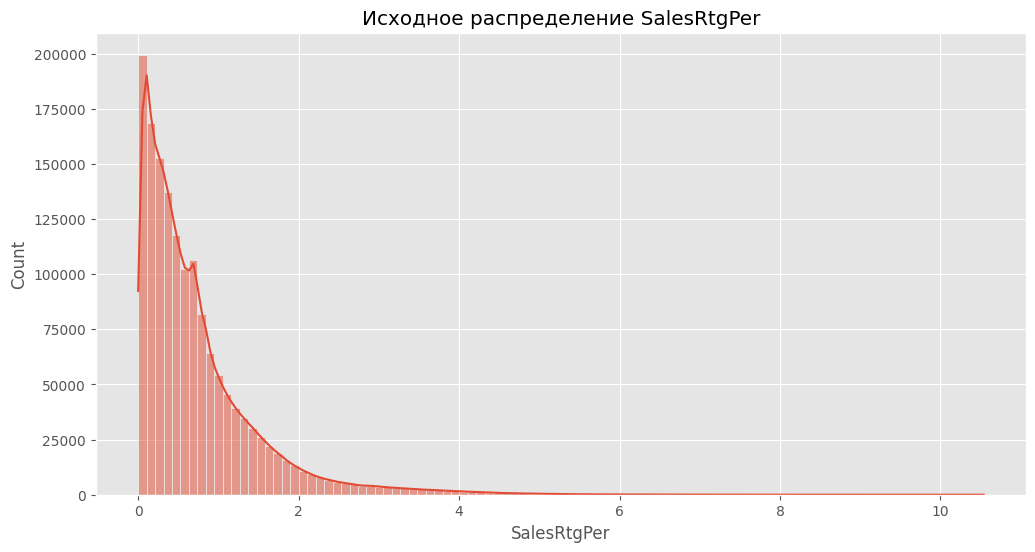

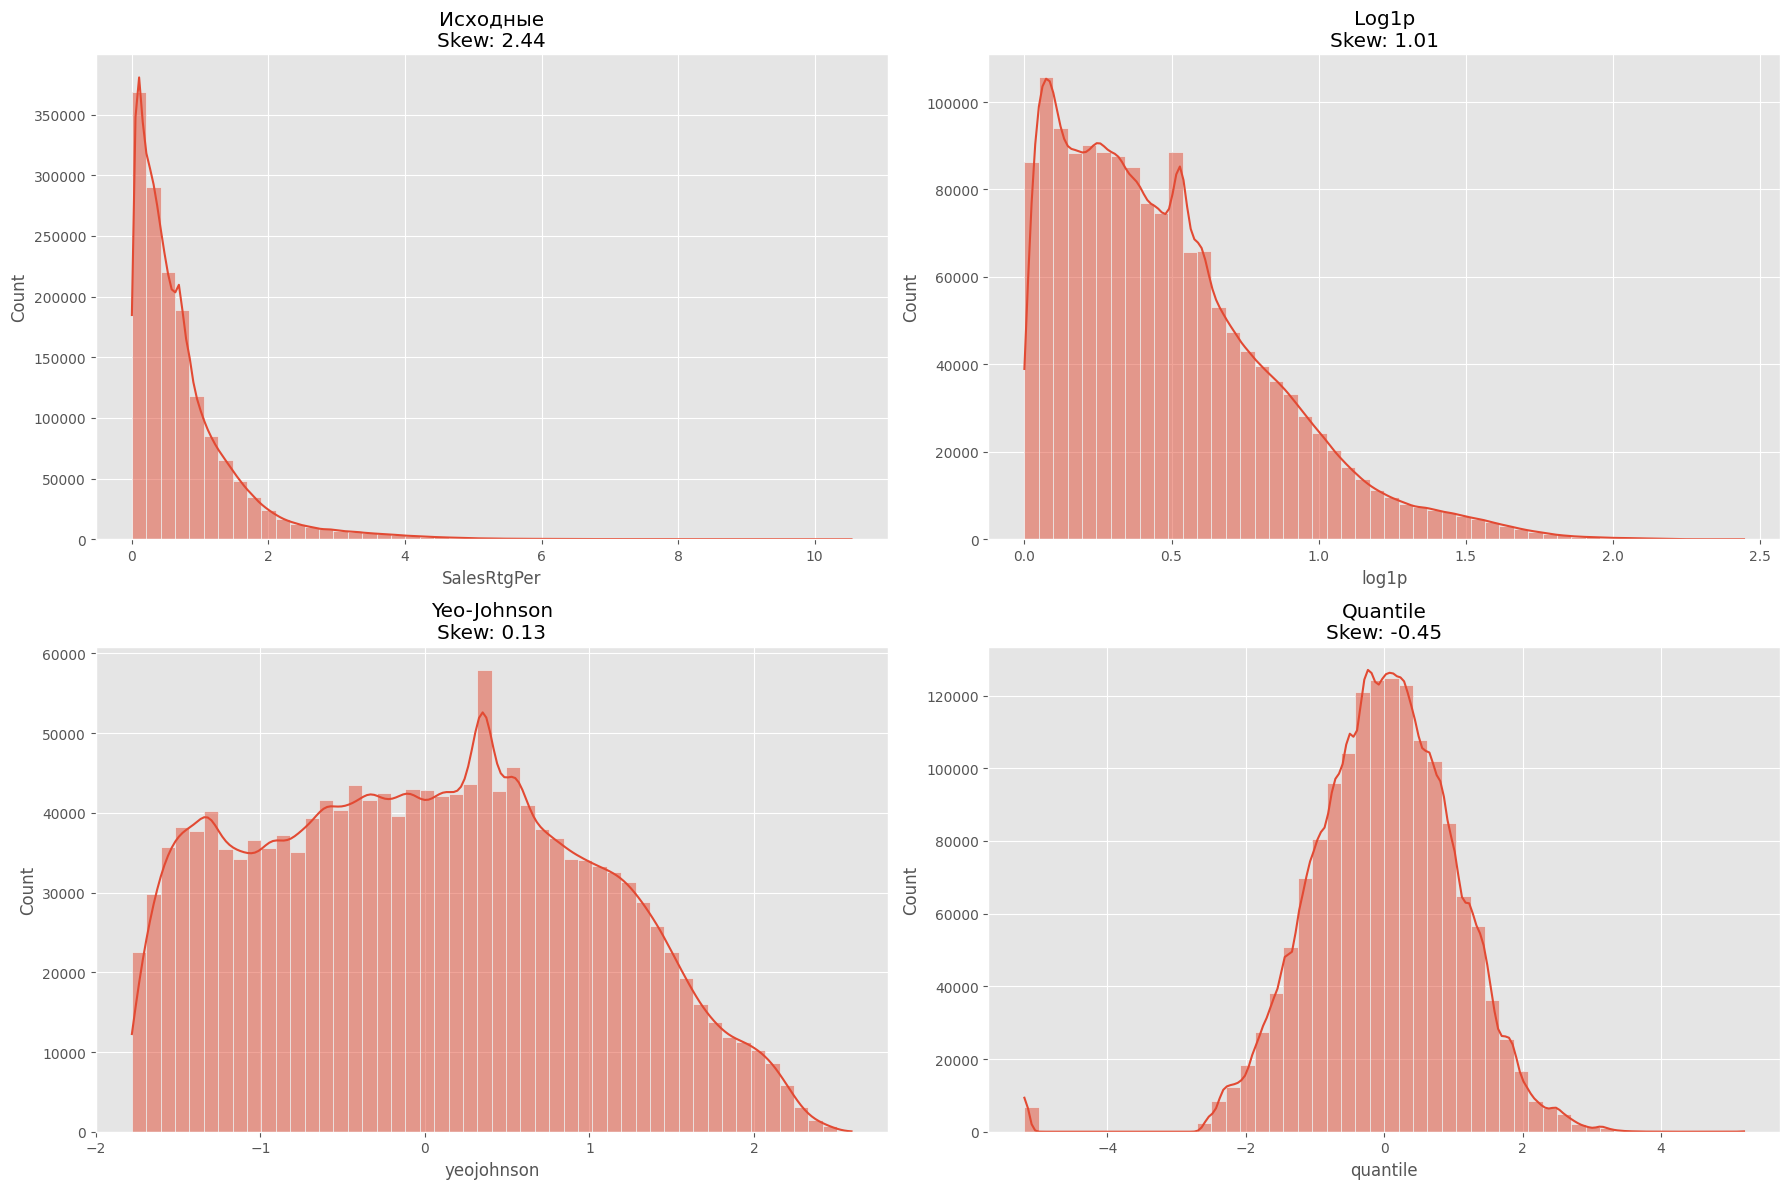


=== Сравнение методов ===
+-------------+------------+---------------------+--------------------+
| Метод       |   Skewness |   Выбросы (1.5*IQR) | Процент выбросов   |
+=============+============+=====================+====================+
| Исходные    |   2.43754  |               85565 | 5.60%              |
+-------------+------------+---------------------+--------------------+
| Log1p       |   1.00523  |               33551 | 2.20%              |
+-------------+------------+---------------------+--------------------+
| Yeo-Johnson |   0.127844 |                   0 | 0.00%              |
+-------------+------------+---------------------+--------------------+
| Quantile    |  -0.450603 |                4491 | 0.29%              |
+-------------+------------+---------------------+--------------------+

=== Пример обратного преобразования ===
log1p:
Преобразованные: [0.5 1.  1.5]
Обратно: [0.64872127 1.71828183 3.48168907]
Разница: [0.14872127 0.71828183 1.98168907]

yeojohnson:
П

In [ ]:
#СТАЛО
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
from scipy.stats.mstats import winsorize

# 1. Анализ исходных данных
print("=== Исходные данные ===")
print(data_encoded['SalesRtgPer'].describe())
plt.figure(figsize=(12, 6))
sns.histplot(data_encoded['SalesRtgPer'], bins=100, kde=True)
plt.title('Исходное распределение SalesRtgPer')
plt.show()

# 2. Логарифмическое преобразование
data_encoded['log1p'] = np.log1p(data_encoded['SalesRtgPer'])

# 3. Yeo-Johnson преобразование
pt = PowerTransformer(method='yeo-johnson')
data_encoded['yeojohnson'] = pt.fit_transform(data_encoded[['SalesRtgPer']])

# 4. Квантильное преобразование
qt = QuantileTransformer(output_distribution='normal')
data_encoded['quantile'] = qt.fit_transform(data_encoded[['SalesRtgPer']])

# Визуализация
plt.figure(figsize=(18, 12))
transformations = ['SalesRtgPer', 'log1p', 'yeojohnson', 'quantile']
titles = ['Исходные', 'Log1p', 'Yeo-Johnson', 'Quantile']

for i, (col, title) in enumerate(zip(transformations, titles), 1):
    plt.subplot(2, 2, i)
    sns.histplot(data_encoded[col], bins=50, kde=True)
    skew = data_encoded[col].skew()
    plt.title(f'{title}\nSkew: {skew:.2f}')
plt.tight_layout()
plt.show()

# Функция для подсчета выбросов
def count_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    return (series > upper_bound).sum()

# Сравнение статистик
print("\n=== Сравнение методов ===")
stats_comparison = pd.DataFrame({
    'Метод': ['Исходные', 'Log1p', 'Yeo-Johnson', 'Quantile'],
    'Skewness': [data_encoded['SalesRtgPer'].skew(),
                data_encoded['log1p'].skew(),
                data_encoded['yeojohnson'].skew(),
                data_encoded['quantile'].skew()],
    'Выбросы (1.5*IQR)': [
        count_outliers(data_encoded['SalesRtgPer']),
        count_outliers(data_encoded['log1p']),
        count_outliers(data_encoded['yeojohnson']),
        count_outliers(data_encoded['quantile'])
    ],
    'Процент выбросов': [
        f"{count_outliers(data_encoded['SalesRtgPer']) / len(data_encoded) * 100:.2f}%",
        f"{count_outliers(data_encoded['log1p']) / len(data_encoded) * 100:.2f}%",
        f"{count_outliers(data_encoded['yeojohnson']) / len(data_encoded) * 100:.2f}%",
        f"{count_outliers(data_encoded['quantile']) / len(data_encoded) * 100:.2f}%"
    ]
})

# Красивое отображение таблицы
print(stats_comparison.to_markdown(tablefmt="grid", index=False))

# Функции для обратного преобразования
def inverse_transform(y_pred, method):
    if method == 'log1p':
        return np.expm1(y_pred)
    elif method == 'yeojohnson':
        return pt.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    elif method == 'quantile':
        return qt.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    else:
        return y_pred

# Пример использования
print("\n=== Пример обратного преобразования ===")
test_values = np.array([0.5, 1.0, 1.5])
for method in ['log1p', 'yeojohnson', 'quantile']:
    original_values = inverse_transform(test_values, method)
    print(f"{method}:")
    print(f"Преобразованные: {test_values}")
    print(f"Обратно: {original_values}")
    print(f"Разница: {original_values - test_values}\n")